## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Your Dataset

**Replace this cell with your own dataset loading code!**

In [2]:
# Example: Load Iris dataset
# REPLACE THIS with your own dataset!
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"\nFeatures: {feature_names}")
print(f"Classes: {target_names}")

Dataset shape: (150, 4)
Number of samples: 150
Number of features: 4
Number of classes: 3

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


## 3. Prepare Data for Analysis

In [3]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.fit_transform(X)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 120 samples
Testing set: 30 samples


## 📚 Understanding Model Functions

Before we dive into the analysis, let's understand the key model functions you'll see throughout this notebook:

### **`model = Algorithm(parameters)`** - Create Model
Creates a new model instance with specified settings.
```python
# Example:
knn = KNeighborsClassifier(n_neighbors=5)  # Create KNN with k=5
```
**Think of it as:** Buying a new, unused machine that needs to be trained.

---

### **`model.fit(X_train, y_train)`** - Train Model
Trains the model by learning patterns from the training data.

**What happens:**
- **KNN**: Memorizes all training data points (no actual "learning")
- **Decision Tree**: Builds the tree structure by finding best splits
- **Random Forest**: Builds 100 trees with random samples
- **SVM**: Finds the optimal boundary between classes

```python
# Example:
model.fit(X_train, y_train)  # Model learns from training data
```
**Think of it as:** Teaching the machine by showing it examples with answers.

---

### **`predictions = model.predict(X_test)`** - Make Predictions
Uses the trained model to predict classes for new data.

**Returns:** Array of predicted class labels (e.g., `[0, 1, 2, 1, 0, ...]`)

```python
# Example:
y_pred = model.predict(X_test)  # [0, 2, 1, 1, ...] - predicted classes
```
**Think of it as:** Asking the machine "What do you think this is?"

---

### **`accuracy = model.score(X_test, y_test)`** - Calculate Accuracy
Predicts AND calculates accuracy in one step.

**Returns:** Accuracy as a decimal (e.g., `0.96` = 96%)

```python
# Example:
test_acc = model.score(X_test, y_test)  # 0.96 (96% correct)

# Equivalent to:
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)  # Same result!
```
**Think of it as:** Taking a test and getting your grade automatically.

---

### **`probs = model.predict_proba(X_test)`** - Get Probabilities
Returns confidence scores for each class (not all models support this).

**Returns:** 2D array where each row = probabilities for one sample

```python
# Example:
probs = model.predict_proba(X_test)
# [[0.1, 0.2, 0.7],   ← Sample 1: 70% sure it's class 2
#  [0.9, 0.05, 0.05], ← Sample 2: 90% sure it's class 0
#  [0.3, 0.6, 0.1]]   ← Sample 3: 60% sure it's class 1
```
**Think of it as:** The machine saying "I'm 70% sure this is class 2."

---

### **Complete Workflow Example:**

```python
# 1. Create model
model = RandomForestClassifier(n_estimators=100)

# 2. Train on training data
model.fit(X_train, y_train)  # Model learns patterns

# 3. Predict on test data
y_pred = model.predict(X_test)  # Get predictions

# 4. Check accuracy
test_acc = model.score(X_test, y_test)  # 0.95 = 95%

# 5. Get probabilities (if supported)
probs = model.predict_proba(X_test)  # Confidence scores
```

---

### **Why Do We Fit and Score Separately?**

**Training phase:**
```python
model.fit(X_train, y_train)  # Learn from 80% of data
```

**Evaluation phase:**
```python
train_acc = model.score(X_train, y_train)  # How well it learned
test_acc = model.score(X_test, y_test)     # How well it generalizes
```

**Key insight:** We NEVER train on test data! That would be like studying the exam questions before the test (cheating!).

---

**Now you're ready to understand all the model operations in this notebook! 🎯**

## 4. Noise Indicator #1: Cross-Validation Variability

**High CV standard deviation = High noise**

**Interpretation:**
- Std < 0.02 → **Low noise** ✅
- Std 0.02-0.05 → **Medium noise** ⚠️
- Std > 0.05 → **High noise** 🔴

In [4]:
# Test with multiple algorithms
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

print("\n" + "="*70)
print("CROSS-VALIDATION VARIABILITY ANALYSIS")
print("="*70)

cv_results = []

for name, model in models.items():
    # Use 10-fold cross-validation
    if name in ['KNN', 'SVM']:
        cv_scores = cross_val_score(model, X_scaled, y, cv=10)
    else:
        cv_scores = cross_val_score(model, X, y, cv=10)
    
    mean_score = cv_scores.mean()
    std_score = cv_scores.std()
    
    cv_results.append({
        'Algorithm': name,
        'CV Mean': mean_score,
        'CV Std': std_score
    })
    
    # Determine noise level based on std
    if std_score < 0.02:
        noise_level = "Low ✅"
    elif std_score < 0.05:
        noise_level = "Medium ⚠️"
    else:
        noise_level = "High 🔴"
    
    print(f"\n{name}:")
    print(f"  Mean Accuracy: {mean_score:.2%}")
    print(f"  Std Deviation: {std_score:.4f}")
    print(f"  Noise Level: {noise_level}")

# Create summary DataFrame
cv_df = pd.DataFrame(cv_results)
avg_std = cv_df['CV Std'].mean()

print(f"\n{'='*70}")
print(f"Average CV Std across all models: {avg_std:.4f}")
if avg_std < 0.02:
    print("Overall Assessment: LOW NOISE DATASET ✅")
elif avg_std < 0.05:
    print("Overall Assessment: MEDIUM NOISE DATASET ⚠️")
else:
    print("Overall Assessment: HIGH NOISE DATASET 🔴")
print(f"{'='*70}")


CROSS-VALIDATION VARIABILITY ANALYSIS

KNN:
  Mean Accuracy: 95.33%
  Std Deviation: 0.0521
  Noise Level: High 🔴

Decision Tree:
  Mean Accuracy: 95.33%
  Std Deviation: 0.0427
  Noise Level: Medium ⚠️

Random Forest:
  Mean Accuracy: 96.00%
  Std Deviation: 0.0327
  Noise Level: Medium ⚠️

SVM:
  Mean Accuracy: 96.67%
  Std Deviation: 0.0447
  Noise Level: Medium ⚠️

Average CV Std across all models: 0.0430
Overall Assessment: MEDIUM NOISE DATASET ⚠️


## 5. Noise Indicator #2: Train-Test Accuracy Gap

**Interpretation:**
- Both train and test are LOW (~70-80%) → **High inherent noise**
- High train (>95%), low test (<85%) → **Overfitting to noise**
- Small gap (<5%) with high scores (>90%) → **Low noise** ✅

In [5]:
print("\n" + "="*70)
print("TRAIN-TEST GAP ANALYSIS")
print("="*70)

gap_results = []

for name, model in models.items():
    # Train model
    if name in ['KNN', 'SVM']:
        model.fit(X_train_scaled, y_train)
        train_acc = model.score(X_train_scaled, y_train)
        test_acc = model.score(X_test_scaled, y_test)
    else:
        model.fit(X_train, y_train)
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
    
    gap = train_acc - test_acc
    
    gap_results.append({
        'Algorithm': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Gap': gap
    })
    
    # Interpret the gap
    if test_acc < 0.80:
        interpretation = "High inherent noise 🔴"
    elif gap > 0.15:
        interpretation = "Overfitting to noise ⚠️"
    elif gap < 0.05 and test_acc > 0.90:
        interpretation = "Low noise ✅"
    else:
        interpretation = "Moderate noise ⚠️"
    
    print(f"\n{name}:")
    print(f"  Train Accuracy: {train_acc:.2%}")
    print(f"  Test Accuracy: {test_acc:.2%}")
    print(f"  Gap: {gap:.2%}")
    print(f"  Interpretation: {interpretation}")

gap_df = pd.DataFrame(gap_results)
avg_gap = gap_df['Gap'].mean()
avg_test = gap_df['Test Acc'].mean()

print(f"\n{'='*70}")
print(f"Average Gap: {avg_gap:.2%}")
print(f"Average Test Accuracy: {avg_test:.2%}")
print(f"{'='*70}")


TRAIN-TEST GAP ANALYSIS

KNN:
  Train Accuracy: 97.50%
  Test Accuracy: 93.33%
  Gap: 4.17%
  Interpretation: Low noise ✅

Decision Tree:
  Train Accuracy: 100.00%
  Test Accuracy: 93.33%
  Gap: 6.67%
  Interpretation: Moderate noise ⚠️

Random Forest:
  Train Accuracy: 100.00%
  Test Accuracy: 90.00%
  Gap: 10.00%
  Interpretation: Moderate noise ⚠️

SVM:
  Train Accuracy: 97.50%
  Test Accuracy: 96.67%
  Gap: 0.83%
  Interpretation: Low noise ✅

Average Gap: 5.42%
Average Test Accuracy: 93.33%


## 6. Noise Indicator #3: Model Agreement Analysis

**Check which samples cause disagreement between models**

Samples where models disagree are likely noisy or ambiguous.

In [6]:
print("\n" + "="*70)
print("MODEL AGREEMENT ANALYSIS")
print("="*70)

# Get predictions from all models
all_predictions = []

for name, model in models.items():
    if name in ['KNN', 'SVM']:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    all_predictions.append(preds)

# Find disagreements
disagreements = []
for i in range(len(X_test)):
    votes = [pred[i] for pred in all_predictions]
    unique_votes = len(set(votes))
    
    if unique_votes > 1:
        disagreements.append({
            'Sample Index': i,
            'Actual': y_test[i],
            'Votes': votes,
            'Agreement': f"{votes.count(max(set(votes), key=votes.count))}/{len(votes)}"
        })

disagreement_rate = len(disagreements) / len(X_test)

print(f"\nTotal test samples: {len(X_test)}")
print(f"Samples with disagreement: {len(disagreements)}")
print(f"Disagreement rate: {disagreement_rate:.2%}")

if disagreement_rate < 0.05:
    print("Assessment: LOW NOISE - Models agree on most samples ✅")
elif disagreement_rate < 0.15:
    print("Assessment: MEDIUM NOISE - Some ambiguous samples ⚠️")
else:
    print("Assessment: HIGH NOISE - Many ambiguous samples 🔴")

if len(disagreements) > 0:
    print(f"\nSamples with disagreement (first 5):")
    for dis in disagreements[:5]:
        print(f"  Sample {dis['Sample Index']}: Actual={dis['Actual']}, Votes={dis['Votes']}, Agreement={dis['Agreement']}")


MODEL AGREEMENT ANALYSIS

Total test samples: 30
Samples with disagreement: 3
Disagreement rate: 10.00%
Assessment: MEDIUM NOISE - Some ambiguous samples ⚠️

Samples with disagreement (first 5):
  Sample 19: Actual=2, Votes=[np.int64(1), np.int64(2), np.int64(1), np.int64(2)], Agreement=2/4
  Sample 23: Actual=2, Votes=[np.int64(1), np.int64(1), np.int64(1), np.int64(2)], Agreement=3/4
  Sample 25: Actual=1, Votes=[np.int64(1), np.int64(2), np.int64(2), np.int64(2)], Agreement=3/4


## 7. Noise Indicator #4: Outlier Detection

**Use Local Outlier Factor to detect anomalies**

**Interpretation:**
- < 5% outliers → **Low noise** ✅
- 5-15% outliers → **Medium noise** ⚠️
- > 15% outliers → **High noise** 🔴


OUTLIER DETECTION ANALYSIS

Total samples: 150
Detected outliers: 6
Outlier ratio: 4.00%
Assessment: LOW NOISE - Few outliers detected ✅


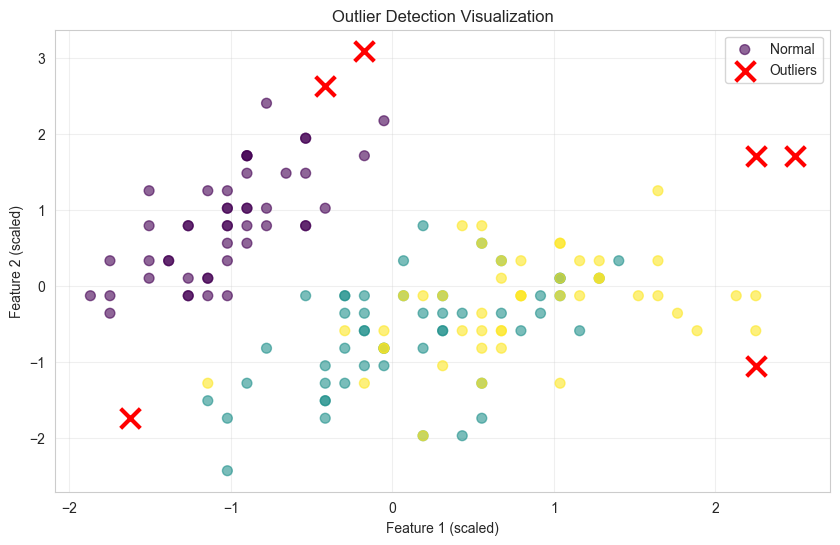

In [7]:
print("\n" + "="*70)
print("OUTLIER DETECTION ANALYSIS")
print("="*70)

# Use Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20)
outlier_labels = lof.fit_predict(X_scaled)

# Count outliers (-1 indicates outlier)
n_outliers = (outlier_labels == -1).sum()
outlier_ratio = n_outliers / len(X)

print(f"\nTotal samples: {len(X)}")
print(f"Detected outliers: {n_outliers}")
print(f"Outlier ratio: {outlier_ratio:.2%}")

if outlier_ratio < 0.05:
    print("Assessment: LOW NOISE - Few outliers detected ✅")
elif outlier_ratio < 0.15:
    print("Assessment: MEDIUM NOISE - Moderate outliers ⚠️")
else:
    print("Assessment: HIGH NOISE - Many outliers detected 🔴")

# Visualize outliers (if 2+ features)
if X.shape[1] >= 2:
    plt.figure(figsize=(10, 6))
    
    # Plot normal points
    normal_mask = outlier_labels == 1
    plt.scatter(X_scaled[normal_mask, 0], X_scaled[normal_mask, 1], 
                c=y[normal_mask], cmap='viridis', alpha=0.6, label='Normal', s=50)
    
    # Plot outliers
    outlier_mask = outlier_labels == -1
    if outlier_mask.any():
        plt.scatter(X_scaled[outlier_mask, 0], X_scaled[outlier_mask, 1], 
                    c='red', marker='x', s=200, linewidths=3, label='Outliers')
    
    plt.xlabel('Feature 1 (scaled)')
    plt.ylabel('Feature 2 (scaled)')
    plt.title('Outlier Detection Visualization')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 8. Noise Indicator #5: Feature-Target Correlation

**Strong correlation = Clear signal = Low noise**

**Interpretation:**
- Max correlation > 0.7 → **Strong signal, low noise** ✅
- Max correlation 0.4-0.7 → **Medium signal** ⚠️
- Max correlation < 0.4 → **Weak signal, high noise** 🔴


FEATURE-TARGET CORRELATION ANALYSIS

Feature-Target Correlations (absolute):
  petal width (cm): 0.9565
  petal length (cm): 0.9490
  sepal length (cm): 0.7826
  sepal width (cm): 0.4267

Maximum correlation: 0.9565
Assessment: STRONG SIGNAL - Low noise expected ✅


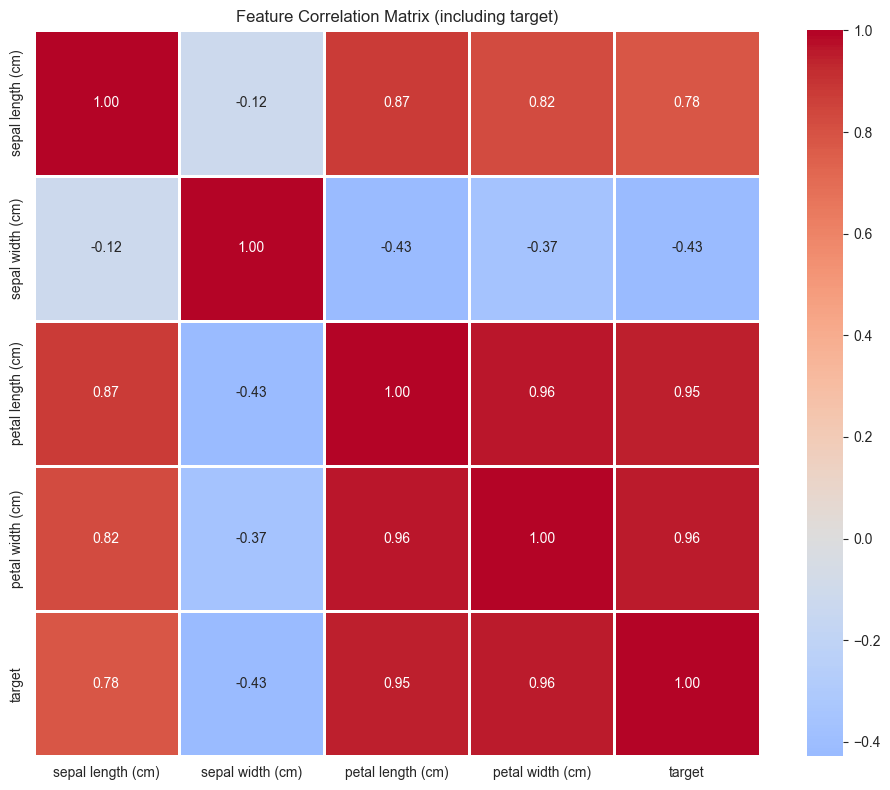

In [8]:
print("\n" + "="*70)
print("FEATURE-TARGET CORRELATION ANALYSIS")
print("="*70)

# Create DataFrame with features and target
df_corr = pd.DataFrame(X, columns=feature_names)
df_corr['target'] = y

# Calculate correlations
correlations = df_corr.corr()['target'].drop('target').abs().sort_values(ascending=False)

print("\nFeature-Target Correlations (absolute):")
for feature, corr in correlations.items():
    print(f"  {feature}: {corr:.4f}")

max_corr = correlations.max()
print(f"\nMaximum correlation: {max_corr:.4f}")

if max_corr > 0.7:
    print("Assessment: STRONG SIGNAL - Low noise expected ✅")
elif max_corr > 0.4:
    print("Assessment: MEDIUM SIGNAL - Moderate noise ⚠️")
else:
    print("Assessment: WEAK SIGNAL - High noise expected 🔴")

# Visualize correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Feature Correlation Matrix (including target)')
plt.tight_layout()
plt.show()

## 9. Noise Indicator #6: Visual Class Separation

**Clear separation = Low noise | Heavy overlap = High noise**


VISUAL CLASS SEPARATION ANALYSIS

Creating pairplot for first 4 features...
Look for:
  ✅ Clear clusters with minimal overlap = Low noise
  ⚠️ Some overlap between classes = Medium noise
  🔴 Heavy overlap, no clear boundaries = High noise


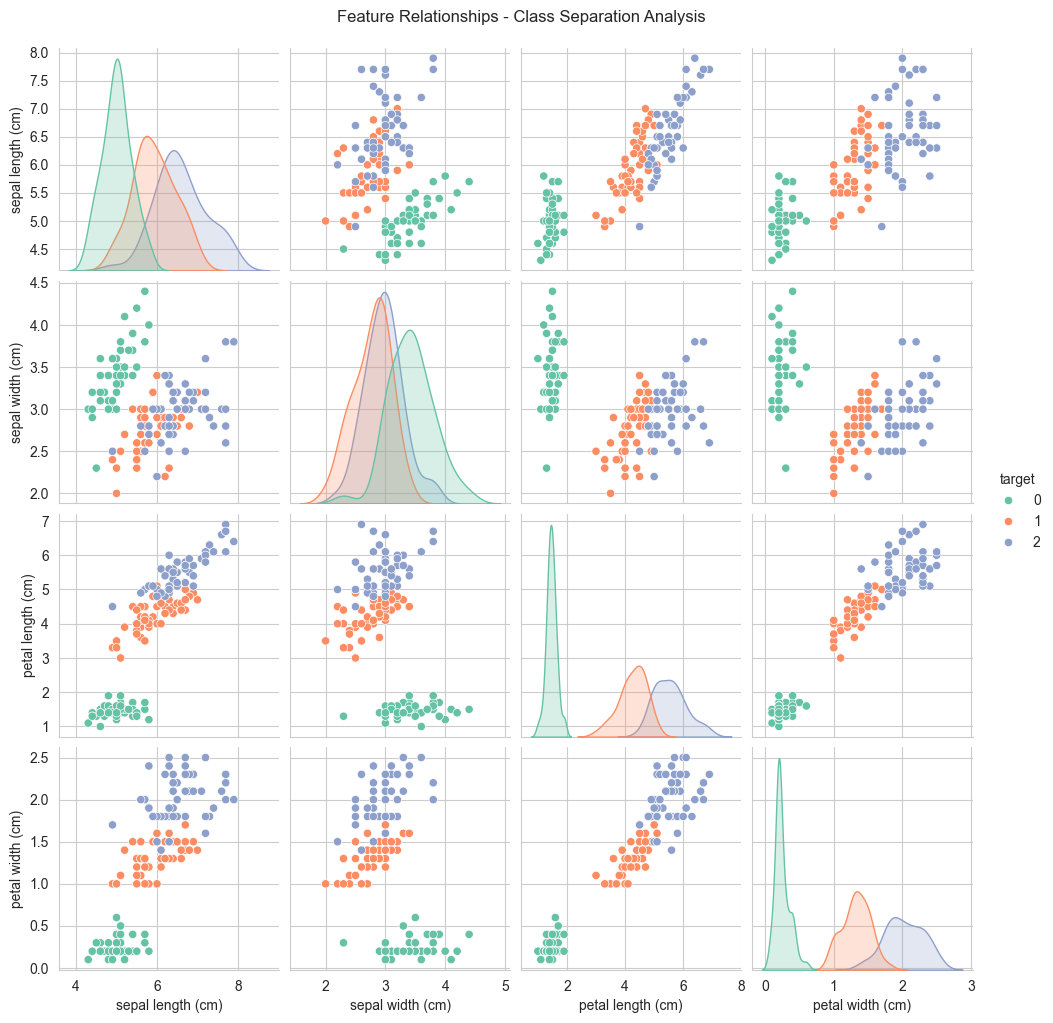

In [9]:
print("\n" + "="*70)
print("VISUAL CLASS SEPARATION ANALYSIS")
print("="*70)

# If more than 2 features, create pairplot
if X.shape[1] >= 2:
    df_viz = pd.DataFrame(X, columns=feature_names)
    df_viz['target'] = y
    
    # Create pairplot for first 4 features (if available)
    n_features_to_plot = min(4, X.shape[1])
    
    print(f"\nCreating pairplot for first {n_features_to_plot} features...")
    print("Look for:")
    print("  ✅ Clear clusters with minimal overlap = Low noise")
    print("  ⚠️ Some overlap between classes = Medium noise")
    print("  🔴 Heavy overlap, no clear boundaries = High noise")
    
    sns.pairplot(df_viz.iloc[:, :n_features_to_plot+1], hue='target', 
                 palette='Set2', diag_kind='kde')
    plt.suptitle('Feature Relationships - Class Separation Analysis', y=1.02)
    plt.show()
else:
    print("\nDataset has only 1 feature - skipping pairplot.")

## 10. Noise Indicator #7: Learning Curve Analysis

**If accuracy plateaus at low values, noise is limiting performance**


LEARNING CURVE ANALYSIS

Final validation accuracy: 96.67%
Assessment: HIGH CEILING - Low noise allows high accuracy ✅


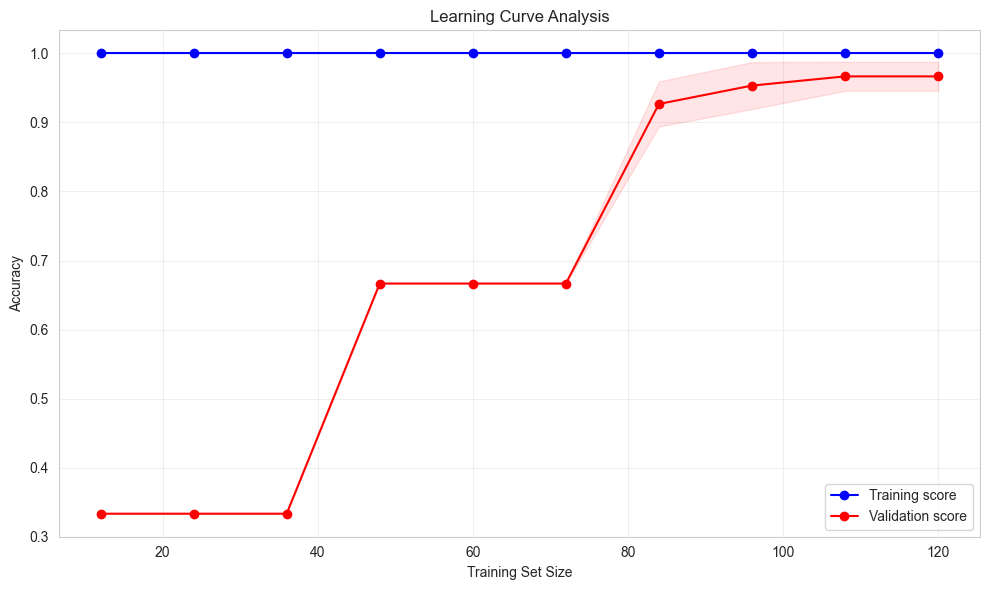


Interpretation:
  - If curves plateau early at low score → High noise ceiling
  - If curves keep improving → More data could help
  - Large gap between train/val → Overfitting to noise


In [10]:
print("\n" + "="*70)
print("LEARNING CURVE ANALYSIS")
print("="*70)

# Use Random Forest for learning curve
model = RandomForestClassifier(n_estimators=100, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Check final validation score
final_val_score = val_mean[-1]

print(f"\nFinal validation accuracy: {final_val_score:.2%}")

if final_val_score > 0.90:
    print("Assessment: HIGH CEILING - Low noise allows high accuracy ✅")
elif final_val_score > 0.75:
    print("Assessment: MEDIUM CEILING - Moderate noise limits accuracy ⚠️")
else:
    print("Assessment: LOW CEILING - High noise prevents high accuracy 🔴")

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.1, color='blue')
plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.1, color='red')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve Analysis')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - If curves plateau early at low score → High noise ceiling")
print("  - If curves keep improving → More data could help")
print("  - Large gap between train/val → Overfitting to noise")

## 11. Final Noise Assessment Summary

In [11]:
print("\n" + "="*70)
print("FINAL NOISE LEVEL ASSESSMENT SUMMARY")
print("="*70)

# Compile all indicators
indicators = {
    'CV Variability (avg std)': avg_std,
    'Train-Test Gap (avg)': avg_gap,
    'Disagreement Rate': disagreement_rate,
    'Outlier Ratio': outlier_ratio,
    'Max Feature Correlation': max_corr,
    'Final Validation Score': final_val_score
}

print("\n📊 Noise Indicators Summary:\n")
for indicator, value in indicators.items():
    print(f"  {indicator}: {value:.4f}")

# Count low-noise indicators
low_noise_count = 0
high_noise_count = 0

if avg_std < 0.02: low_noise_count += 1
elif avg_std > 0.05: high_noise_count += 1

if avg_gap < 0.05 and avg_test > 0.90: low_noise_count += 1
elif avg_test < 0.80 or avg_gap > 0.15: high_noise_count += 1

if disagreement_rate < 0.05: low_noise_count += 1
elif disagreement_rate > 0.15: high_noise_count += 1

if outlier_ratio < 0.05: low_noise_count += 1
elif outlier_ratio > 0.15: high_noise_count += 1

if max_corr > 0.7: low_noise_count += 1
elif max_corr < 0.4: high_noise_count += 1

if final_val_score > 0.90: low_noise_count += 1
elif final_val_score < 0.75: high_noise_count += 1

print(f"\n{'='*70}")
print(f"Low Noise Indicators: {low_noise_count}/6")
print(f"High Noise Indicators: {high_noise_count}/6")

if low_noise_count >= 4:
    print("\n🎯 FINAL VERDICT: LOW NOISE DATASET ✅")
    print("\nRecommendations:")
    print("  ✅ Simple models (KNN, Decision Trees) should work well")
    print("  ✅ Less data augmentation needed")
    print("  ✅ Focus on feature engineering and hyperparameter tuning")
elif high_noise_count >= 4:
    print("\n⚠️ FINAL VERDICT: HIGH NOISE DATASET 🔴")
    print("\nRecommendations:")
    print("  🔴 Use robust models (Random Forest, Gradient Boosting)")
    print("  🔴 Consider data cleaning and outlier removal")
    print("  🔴 More data and cross-validation essential")
    print("  🔴 Set realistic accuracy expectations")
else:
    print("\n📊 FINAL VERDICT: MEDIUM NOISE DATASET ⚠️")
    print("\nRecommendations:")
    print("  ⚠️ Balance between simple and complex models")
    print("  ⚠️ Use cross-validation for reliable evaluation")
    print("  ⚠️ Consider ensemble methods for robustness")
    print("  ⚠️ Monitor for overfitting")

print(f"{'='*70}")


FINAL NOISE LEVEL ASSESSMENT SUMMARY

📊 Noise Indicators Summary:

  CV Variability (avg std): 0.0430
  Train-Test Gap (avg): 0.0542
  Disagreement Rate: 0.1000
  Outlier Ratio: 0.0400
  Max Feature Correlation: 0.9565
  Final Validation Score: 0.9667

Low Noise Indicators: 3/6
High Noise Indicators: 0/6

📊 FINAL VERDICT: MEDIUM NOISE DATASET ⚠️

Recommendations:
  ⚠️ Balance between simple and complex models
  ⚠️ Use cross-validation for reliable evaluation
  ⚠️ Consider ensemble methods for robustness
  ⚠️ Monitor for overfitting
